# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

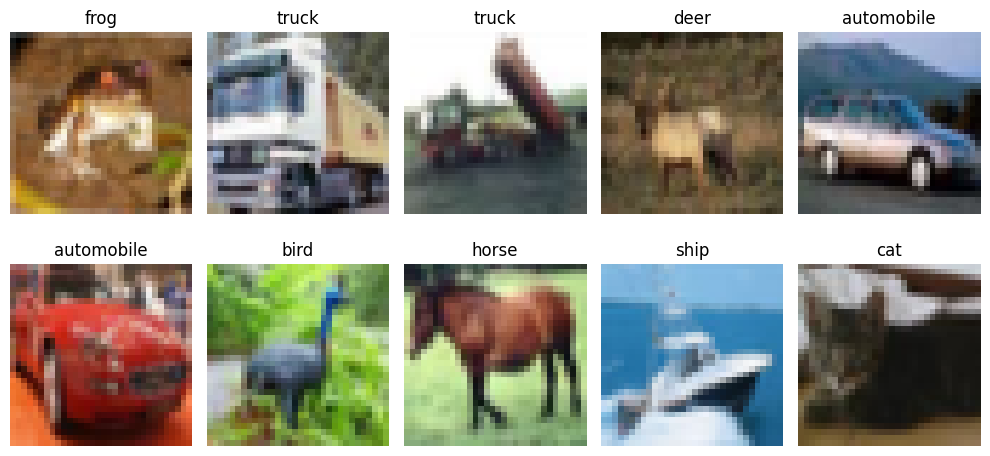

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
layers.Input(shape=(3072,)), #replaced deprecated input_shape in Dense with separate Input layer
layers.Dense(512, activation='relu'),
layers.Dropout(0.3),
layers.Dense(256, activation='relu'),
layers.Dropout(0.3), #added dropout after second Dense to reduce overfittting
layers.Dense(128, activation='relu'), #added extra Dense layer for better learning
layers.Dense(10, activation='softmax')
])

ann_model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

ann_history = ann_model.fit(
x_train_flat, y_train,
epochs=10,
validation_split=0.1,
batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.2456 - loss: 2.0389 - val_accuracy: 0.3126 - val_loss: 1.8936
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3021 - loss: 1.8930 - val_accuracy: 0.3400 - val_loss: 1.8238
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3182 - loss: 1.8521 - val_accuracy: 0.3538 - val_loss: 1.8025
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3318 - loss: 1.8220 - val_accuracy: 0.3834 - val_loss: 1.7427
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3434 - loss: 1.7924 - val_accuracy: 0.3830 - val_loss: 1.7447
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3522 - loss: 1.7730 - val_accuracy: 0.3916 - val_loss: 1.7188
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3581 - loss: 1.7599 - val_accuracy: 0.4038 - val_loss: 1.7076
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3633 - loss: 1.7465 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4150 - loss: 1.6530
ANN Test Accuracy: 0.41499999165534973


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
layers.Input(shape=(32, 32, 3)),
layers.Conv2D(32, (3,3), activation='relu', padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),

layers.Conv2D(64, (3,3), activation='relu', padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),

layers.Conv2D(128, (3,3), activation='relu', padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),

layers.Flatten(),
layers.Dense(256, activation='relu'),
layers.Dropout(0.4),
layers.Dense(10, activation='softmax')
])

cnn_model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

cnn_history = cnn_model.fit(
x_train_norm, y_train,
epochs=10,
validation_split=0.1,
batch_size=64,
callbacks=[early_stop]
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 126s 175ms/step - accuracy: 0.4763 - loss: 1.4847 - val_accuracy: 0.4492 - val_loss: 1.6686
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.6234 - loss: 1.0715 - val_accuracy: 0.6388 - val_loss: 1.0273
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 170ms/step - accuracy: 0.6850 - loss: 0.9026 - val_accuracy: 0.6528 - val_loss: 0.9669
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 168ms/step - accuracy: 0.7259 - loss: 0.7794 - val_accuracy: 0.7122 - val_loss: 0.8413
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 168ms/step - accuracy: 0.7602 - loss: 0.6898 - val_accuracy: 0.6880 - val_loss: 0.9076
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 167ms/step - accuracy: 0.7865 - loss: 0.6118 - val_accuracy: 0.7398 - val_loss: 0.7845
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 121s 172ms/step - accuracy: 0.8120 - loss: 0.5290 - val_accuracy: 0.7714 - val_loss: 0.7338
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 117s 167ms/step - accuracy: 0.8329 -

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7559 - loss: 0.7718
CNN Test Accuracy: 0.7559000253677368


## 📈 Compare Learning Curves

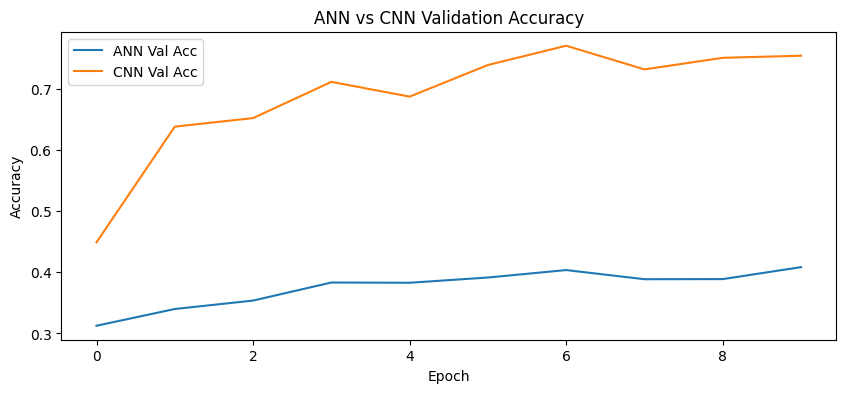

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
layers.Input(shape=(32,32,3)),
data_augmentation,
layers.Conv2D(32, 3, activation='relu', padding='same'),
layers.MaxPooling2D(),
layers.Conv2D(64, 3, activation='relu', padding='same'),
layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dropout(0.4),
layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.3910 - loss: 1.6812 - val_accuracy: 0.5160 - val_loss: 1.3449
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.4880 - loss: 1.4308 - val_accuracy: 0.5954 - val_loss: 1.1429
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 56ms/step - accuracy: 0.5249 - loss: 1.3337 - val_accuracy: 0.6070 - val_loss: 1.1198
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.5450 - loss: 1.2776 - val_accuracy: 0.6272 - val_loss: 1.0498
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.5622 - loss: 1.2410 - val_accuracy: 0.6308 - val_loss: 1.0548
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.5749 - loss: 1.2057 - val_accuracy: 0.6396 - val_loss: 1.0376
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 58ms/step - accuracy: 0.5849 - loss: 1.1783 - val_accuracy: 0.6462 - val_loss: 1.0056
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 56ms/step - accuracy: 0.5924 -

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4150
1,CNN,0.7559


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**